In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math
import yfinance as yf
import pandas as pd
import seaborn as sns
import seaborn.objects as so
from keras import Input
from keras import layers, Model
import tensorflow as tf
from tensorflow.keras.optimizers import RMSprop, Adam, SGD
import random
import sys
sys.path.append('../..')
#import ep.etools as apt
# import warnings
# warnings.filterwarnings( "ignore", module = "matplotlib\..*" )
from tqdm import tqdm
from pandas.tseries.offsets import DateOffset,BusinessDay
from sklearn.preprocessing import MinMaxScaler

,Day-ahead,Month-ahead,Quarter-ahead,Summer 24,Winter 24,Year-Ahead,2 Year-Ahead
date_m,,,,,,,
2010-01-01,14.30,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,16.25,13.70,NaN,NaN,NaN,NaN,NaN
2010-01-05,14.15,13.96,NaN,NaN,NaN,NaN,NaN
2010-01-06,14.65,13.80,NaN,NaN,NaN,NaN,NaN
2010-01-07,16.18,13.82,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2024-04-22,29.78,29.20,29.91,NaN,34.61,33.40,29.72
2024-04-23,29.09,28.58,29.16,NaN,33.91,33.00,29.50
2024-04-24,30.11,29.33,29.80,NaN,34.38,33.58,29.83


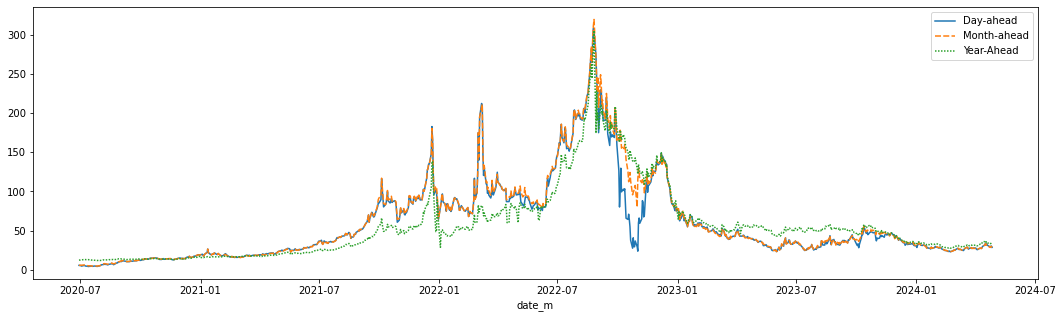

In [4]:
# dataCalendar = pd.read_csv('./data/bloc_ttf_calendar_prices.csv')
dataPrices = pd.read_csv('../../data/bloc_ttf_prices.csv')
dataPrices['date_m'] = pd.to_datetime(dataPrices['date_m'])
dataPrices = dataPrices.set_index('date_m')
fig, ax = plt.subplots(figsize=(18,5))
# sns.set_palette("mako")
sns.lineplot(dataPrices[['Day-ahead','Month-ahead','Year-Ahead']][-1000:], color='Blue'); #3390
#ax2 = plt.twinx()
#sns.lineplot(data=final['€/$'], ax=ax2 , color='grey')
dataPrices

In [5]:
def Normalize(d,r):
    seuil = int(d.size*(1-r))
    min_max_scaler = MinMaxScaler()
    # définir le scaler à partir de l'ensemble des données
    scaler = min_max_scaler.fit(d.reshape(-1, 1))
    # mise à l'échelle des données d'apprentissage et de test
    train = scaler.transform(d[:seuil].reshape(-1, 1))
    test = scaler.transform(d[seuil:].reshape(-1, 1))
    return train, test, min_max_scaler

In [6]:
def WindowHash(dataset, start_index, end_index, history_size,mask, forward):
    data = []
    labels = []

    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset)-mask-forward+1

    for i in range(start_index, end_index):
        indices = range(i - history_size, i)
        indicesY = range(i-mask,i+forward)
        data.append(np.reshape(dataset[indices], (history_size, 1)))
        # labels.append(np.reshape(dataset[i-mask:i+forward],(forward+mask-1,1)))
        # labels.append((dataset[i-mask:i+forward]))
        labels.append((dataset[indicesY]))

    return np.array(data), np.array(labels)

In [7]:
from tensorflow import math, matmul, reshape, shape, transpose, cast, float32
from tensorflow.keras.layers import Dense, Layer, Dropout
from keras.backend import softmax
from numpy import random
# import tensorflow as tf
# from tensorflow import convert_to_tensor, string
from tensorflow.keras.layers import TextVectorization, Embedding
from tensorflow.data import Dataset
import numpy as np

In [135]:
class PositionEmbeddingFixedWeights(Layer):
    # def __init__(self, sequence_length, output_dim, **kwargs):
    def __init__(self, sequence_length, output_dim, **kwargs):
        super(PositionEmbeddingFixedWeights, self).__init__(**kwargs)
        position_embedding_matrix = self.get_position_encoding(sequence_length, output_dim)
        word_embedding_matrix = self.get_position_encoding(sequence_length, output_dim)                                 
        self.word_embedding_layer = Embedding(
            input_dim=sequence_length, output_dim=output_dim,
            weights=[word_embedding_matrix],
            trainable=False
        )
        self.position_embedding_layer = Embedding(
            input_dim=sequence_length, output_dim=output_dim,
            weights=[position_embedding_matrix],
            trainable=False
        )
             
    def get_position_encoding(self, seq_len, d, n=10000):
        P = np.zeros((seq_len, d))
        for k in range(seq_len):
            for i in np.arange(int(d/2)):
                denominator = np.power(n, 2*i/d)
                P[k, 2*i] = np.sin(k/denominator)
                P[k, 2*i+1] = np.cos(k/denominator)
        return P
 
 
    def call(self, inputs):        
        position_indices = tf.range(tf.shape(inputs)[-1])
        embedded_indices = self.position_embedding_layer(position_indices)
        embedded_words = self.word_embedding_layer(inputs)
        return embedded_words+embedded_indices

TypeError: Invalid shape (64, 20, 512) for image data

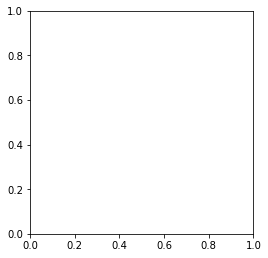

In [136]:
## TEST POSITION EMBEDDING

pC = PositionEmbeddingFixedWeights(100,512)
#P = getPositionEncoding(seq_len=100, d=512, n=10000)
input_seq = random.random((64, 20))
P = pC(input_seq)
cax = plt.matshow(P)
plt.gcf().colorbar(cax)

In [111]:
# Implementing the Scaled-Dot Product Attention
class DotProductAttention(Layer):
    def __init__(self, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
 
    def call(self, queries, keys, values, mask=None):
        dK = keys.shape[-1]
        # Scoring the queries against the keys after transposing the latter, and scaling
        scores = matmul(queries, keys, transpose_b=True) / math.sqrt(cast(dK, float32))
 
        # Apply mask to the attention scores
        if mask is not None:
            scores += -1e9 * mask # or (1.-mask)
 
        # Computing the weights by a softmax operation
        weights = softmax(scores)
 
        # Computing the attention by a weighted sum of the value vectors
        return matmul(weights, values), weights

In [112]:
## TEST DOT PRODUCT
input_seq_length = 5  # Maximum length of the input sequence
h = 8  # Number of self-attention heads
d_k = 64  # Dimensionality of the linearly projected queries and keys
d_v = 64  # Dimensionality of the linearly projected values
d_model = 512  # Dimensionality of the model sub-layers' outputs

batch_size = 64  # Batch size from the training process

queries = random.random((batch_size, input_seq_length, d_k))
keys = random.random((batch_size, input_seq_length, d_k))
values = random.random((batch_size, input_seq_length, d_v))

dP = DotProductAttention()
out,_ = dP(queries,keys,values)
print(out)

tf.Tensor(
[[[0.34603336 0.6056637  0.4927033  ... 0.43194824 0.59100044 0.58088756]
  [0.33852127 0.6013814  0.4869884  ... 0.43647742 0.5901474  0.5927845 ]
  [0.33053446 0.5704373  0.5170082  ... 0.4459311  0.5915247  0.58996177]
  [0.3404612  0.5891726  0.49521905 ... 0.44270787 0.59241843 0.59045804]
  [0.33665374 0.6055349  0.48338944 ... 0.43445277 0.5888339  0.5949481 ]]

 [[0.53494656 0.6571108  0.39654586 ... 0.6447948  0.50797015 0.6500352 ]
  [0.53877616 0.68261814 0.39912546 ... 0.6477227  0.5336007  0.6416193 ]
  [0.5336017  0.6733045  0.3925311  ... 0.6515132  0.52661824 0.64869094]
  [0.5309193  0.6956161  0.41597572 ... 0.6590062  0.5509476  0.633952  ]
  [0.5265814  0.6727971  0.40991688 ... 0.66267335 0.5285522  0.64111125]]

 [[0.4206276  0.2710707  0.59629524 ... 0.58939314 0.39468417 0.6554296 ]
  [0.43142432 0.25231186 0.61220175 ... 0.61482346 0.36499614 0.6636917 ]
  [0.41944525 0.25421453 0.60654867 ... 0.6079514  0.3814878  0.65051675]
  [0.43380046 0.2737087

In [122]:
# Implementing the Multi-Head Attention
class MultiHeadAttention(Layer):
    def __init__(self, h, dK, dV, dModel, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.attention = DotProductAttention()  # Scaled dot product attention
        self.heads = h  # Number of attention heads to use
        self.dK = dK  # Dimensionality of the linearly projected queries and keys
        self.dV = dV  # Dimensionality of the linearly projected values
        self.dModel = dModel  # Dimensionality of the model
        self.wQ = Dense(dK)  # Learned projection matrix for the queries
        self.wK = Dense(dK)  # Learned projection matrix for the keys
        self.wV = Dense(dV)  # Learned projection matrix for the values
        self.wOut = Dense(dModel)  # Learned projection matrix for the multi-head output
        initializer = tf.keras.initializers.GlorotUniform()
        self.WQ = tf.Variable(initializer(shape=(h, dModel, dK)), trainable=True)
        self.WK = tf.Variable(initializer(shape=(h, dModel, dK)), trainable=True)
        self.WV = tf.Variable(initializer(shape=(h, dModel, dV)), trainable=True)
        self.WO = tf.Variable(initializer(shape=(h*dV,dModel)), trainable=True)
 
    def reshape_tensor(self, x, heads, flag):
        if flag:
            # Tensor shape after reshaping and transposing: (batch_size, heads, seq_length, -1)
            print(x.shape,heads)
            # x = reshape(x, shape=(shape(x)[0], heads, -1))
            x = reshape(x, shape=(shape(x)[0], shape(x)[1], heads, -1))
            x = transpose(x, perm=(0, 2, 1, 3))
        else:
            # Reverting the reshaping and transposing operations: (batch_size, seq_length, d_k)
            x = transpose(x, perm=(0, 2, 1, 3))
            x = reshape(x, shape=(shape(x)[0], shape(x)[1], self.dK))
        return x
    
    def projection(self,x,w):
        print('x',x.shape,'w', w.shape)
        x = tf.experimental.numpy.dot(x,w)
        x = tf.transpose(x, [0,2,1,3])
        return x
 
    def call(self, queries, keys, values, mask=None):
    # def call(self, queries, keys, values, Q, K, V, mask=None):
        # Rearrange the queries to be able to compute all heads in parallel
        q_reshaped = self.reshape_tensor(self.wQ(queries), self.heads, True)
        # print('q_rechape',q_reshaped.shape)
        # qh = self.wQ(queries)
        # print('qh',qh.shape)
        # hQ = self.projection(Q,self.WQ)
        # print('hQ',hQ.shape)
        # Resulting tensor shape: (batch_size, heads, input_seq_length, -1)
 
        # Rearrange the keys to be able to compute all heads in parallel
        k_reshaped = self.reshape_tensor(self.wK(keys), self.heads, True)
        # hK = self.projection(self.wK(keys))
        # hK = self.projection(K,self.WK)
        # Resulting tensor shape: (batch_size, heads, input_seq_length, -1)
 
        # Rearrange the values to be able to compute all heads in parallel
        v_reshaped = self.reshape_tensor(self.wV(values), self.heads, True)
        # hV = self.projection(self.wV(values))
        # hV = self.projection(V,self.WV)
        # Resulting tensor shape: (batch_size, heads, input_seq_length, -1)
 
        # Compute the multi-head attention output using the reshaped queries, keys and values
        print(q_reshaped.shape,k_reshaped.shape,v_reshaped.shape)
        o_reshaped,_ = self.attention(q_reshaped, k_reshaped, v_reshaped, mask)
        print('o_shape',o_reshaped.shape)
        # out = self.attention(hQ,hK,hV,self.dK,mask)
        # print(hQ.shape,hK.shape, hV.shape)
        # out,_=self.attention(hQ, hK, hV, mask=mask) #of shape (batch_size, H, Tq, dv)
        # Resulting tensor shape: (batch_size, heads, input_seq_length, -1)
 
        # Rearrange back the output into concatenated form
        output = self.reshape_tensor(o_reshaped, self.heads, False)
        # s = out.shape
        # nOutput = tf.reshape(out,(s[0],s[2],s[1]*s[3]))
        # Resulting tensor shape: (batch_size, input_seq_length, d_v)
 
        # Apply one final linear projection to the output to generate the multi-head attention
        # Resulting tensor shape: (batch_size, input_seq_length, d_model)
        # return self.wOut(nOutput), self.wOut(output)
        return self.wOut(output)

In [125]:
# TEST MULTI HEAD ATTENTION --
input_seq_length = 20  # Maximum length of the input sequence
h = 8  # Number of self-attention heads
d_k = 64  # Dimensionality of the linearly projected queries and keys
d_v = 64  # Dimensionality of the linearly projected values
d_model = 512  # Dimensionality of the model sub-layers' outputs
batch_size = 32  # Batch size from the training process
 
queries = random.random((batch_size, input_seq_length, d_k))
keys = random.random((batch_size, input_seq_length, d_k))
values = random.random((batch_size, input_seq_length, d_v))

Q = random.random((batch_size, d_k,d_model))
K = random.random((batch_size, d_k, d_model))
V = random.random((batch_size, d_v,d_model))

multihead_attention = MultiHeadAttention(h, d_k, d_v, d_model)
b = multihead_attention(queries, keys, values)
# a,b = multihead_attention(queries, keys, values, Q,K,V)
print(b.shape)

(32, 20, 64) 8
(32, 20, 64) 8
(32, 20, 64) 8
(32, 8, 20, 8) (32, 8, 20, 8) (32, 8, 20, 8)
o_shape (32, 8, 20, 8)
(32, 20, 512)


In [126]:
from tensorflow.keras.layers import LayerNormalization, Layer, Dense, ReLU, Dropout
 
# Implementing the Add & Norm Layer
class AddNormalization(Layer):
    def __init__(self, **kwargs):
        super(AddNormalization, self).__init__(**kwargs)
        self.layer_norm = LayerNormalization()  # Layer normalization layer
 
    def call(self, x, sublayer_x):
        # The sublayer input and output need to be of the same shape to be summed
        add = x + sublayer_x
 
        # Apply layer normalization to the sum
        return self.layer_norm(add)
 
# Implementing the Feed-Forward Layer
class FeedForward(Layer):
    def __init__(self, d_ff, d_model, **kwargs):
        super(FeedForward, self).__init__(**kwargs)
        self.fully_connected1 = Dense(d_ff)  # First fully connected layer
        self.fully_connected2 = Dense(d_model)  # Second fully connected layer
        self.activation = ReLU()  # ReLU activation layer
 
    def call(self, x):
        # The input is passed into the two fully-connected layers, with a ReLU in between
        x_fc1 = self.fully_connected1(x)
 
        return self.fully_connected2(self.activation(x_fc1))
 
# Implementing the Encoder Layer
class EncoderLayer(Layer):
    def __init__(self, sequence_length, h, d_k, d_v, d_model, d_ff, rate, **kwargs):
        super(EncoderLayer, self).__init__(**kwargs)
        self.build(input_shape=[None, sequence_length, d_model])
        self.d_model = d_model
        self.sequence_length = sequence_length
        self.multihead_attention = MultiHeadAttention(h, d_k, d_v, d_model)
        self.dropout1 = Dropout(rate)
        self.add_norm1 = AddNormalization()
        self.feed_forward = FeedForward(d_ff, d_model)
        self.dropout2 = Dropout(rate)
        self.add_norm2 = AddNormalization()
    
    def build_graph(self):
        input_layer = Input(shape=(self.sequence_length, self.d_model))
        return Model(inputs=[input_layer], outputs=self.call(input_layer, None, True))

    def call(self, x, padding_mask, training):
        # Multi-head attention layer
        multihead_output = self.multihead_attention(x, x, x, padding_mask)
        # Expected output shape = (batch_size, sequence_length, d_model)
 
        # Add in a dropout layer
        multihead_output = self.dropout1(multihead_output, training=training)
 
        # Followed by an Add & Norm layer
        addnorm_output = self.add_norm1(x, multihead_output)
        # Expected output shape = (batch_size, sequence_length, d_model)
 
        # Followed by a fully connected layer
        feedforward_output = self.feed_forward(addnorm_output)
        # Expected output shape = (batch_size, sequence_length, d_model)
 
        # Add in another dropout layer
        feedforward_output = self.dropout2(feedforward_output, training=training)
 
        # Followed by another Add & Norm layer
        return self.add_norm2(addnorm_output, feedforward_output)
 
# Implementing the Encoder
class Encoder(Layer):
    def __init__(self, sequence_length, h, d_k, d_v, d_model, d_ff, n, rate, **kwargs):
        super(Encoder, self).__init__(**kwargs)
        self.pos_encoding = PositionEmbeddingFixedWeights(sequence_length, d_model)
        self.dropout = Dropout(rate)
        self.encoder_layer = [EncoderLayer(sequence_length, h, d_k, d_v, d_model, d_ff, rate) for _ in range(n)]
 
    def call(self, input_sentence, padding_mask, training):
        # Generate the positional encoding
        pos_encoding_output = self.pos_encoding(input_sentence)
        print('pos out', pos_encoding_output.shape )
        # Expected output shape = (batch_size, sequence_length, d_model)
 
        # Add in a dropout layer
        x = self.dropout(pos_encoding_output, training=training)
 
        # Pass on the positional encoded values to each encoder layer
        print('padding mask', padding_mask)
        for i, layer in enumerate(self.encoder_layer):
            print('x',x.shape)
            x = layer(x, padding_mask, training)
 
        return x

In [137]:
## TEST ENCODER

input_seq_length = 5  # Maximum length of the input sequence
h = 8  # Number of self-attention heads
d_k = 64  # Dimensionality of the linearly projected queries and keys
d_v = 64  # Dimensionality of the linearly projected values
d_ff = 2048  # Dimensionality of the inner fully connected layer
d_model = 512  # Dimensionality of the model sub-layers' outputs
n = 6  # Number of layers in the encoder stack
 
batch_size = 64  # Batch size from the training process
dropout_rate = 0.1  # Frequency of dropping the input units in the dropout layers
 
input_seq = random.random((batch_size, input_seq_length))
 
encoder = Encoder(input_seq_length, h, d_k, d_v, d_model, d_ff, n, dropout_rate)
print(encoder(input_seq, None, True))

pos out (64, 5, 512)
padding mask None
x (64, 5, 512)
(64, 5, 64) 8
(64, 5, 64) 8
(64, 5, 64) 8
(64, 8, 5, 8) (64, 8, 5, 8) (64, 8, 5, 8)
o_shape (64, 8, 5, 8)
x (64, 5, 512)
(64, 5, 64) 8
(64, 5, 64) 8
(64, 5, 64) 8
(64, 8, 5, 8) (64, 8, 5, 8) (64, 8, 5, 8)
o_shape (64, 8, 5, 8)
x (64, 5, 512)
(64, 5, 64) 8
(64, 5, 64) 8
(64, 5, 64) 8
(64, 8, 5, 8) (64, 8, 5, 8) (64, 8, 5, 8)
o_shape (64, 8, 5, 8)
x (64, 5, 512)
(64, 5, 64) 8
(64, 5, 64) 8
(64, 5, 64) 8
(64, 8, 5, 8) (64, 8, 5, 8) (64, 8, 5, 8)
o_shape (64, 8, 5, 8)
x (64, 5, 512)
(64, 5, 64) 8
(64, 5, 64) 8
(64, 5, 64) 8
(64, 8, 5, 8) (64, 8, 5, 8) (64, 8, 5, 8)
o_shape (64, 8, 5, 8)
x (64, 5, 512)
(64, 5, 64) 8
(64, 5, 64) 8
(64, 5, 64) 8
(64, 8, 5, 8) (64, 8, 5, 8) (64, 8, 5, 8)
o_shape (64, 8, 5, 8)
tf.Tensor(
[[[ 8.4064469e-02 -1.0254296e+00 -7.9183227e-01 ...  1.4978178e+00
   -2.1105568e+00  1.0531352e+00]
  [ 2.5024521e-01  4.1377891e-02 -8.2857221e-01 ...  1.6675810e+00
   -1.5960848e+00  1.0252622e+00]
  [ 2.9547265e-02 -8.6

In [140]:
# Implementing the Decoder Layer
class DecoderLayer(Layer):
    def __init__(self, sequence_length, h, d_k, d_v, d_model, d_ff, rate, **kwargs):
        super(DecoderLayer, self).__init__(**kwargs)
        self.build(input_shape=[None, sequence_length, d_model])
        self.d_model = d_model
        self.sequence_length = sequence_length
        self.multihead_attention1 = MultiHeadAttention(h, d_k, d_v, d_model)
        self.dropout1 = Dropout(rate)
        self.add_norm1 = AddNormalization()
        self.multihead_attention2 = MultiHeadAttention(h, d_k, d_v, d_model)
        self.dropout2 = Dropout(rate)
        self.add_norm2 = AddNormalization()
        self.feed_forward = FeedForward(d_ff, d_model)
        self.dropout3 = Dropout(rate)
        self.add_norm3 = AddNormalization()
        
    def build_graph(self):
        input_layer = Input(shape=(self.sequence_length, self.d_model))
        return Model(inputs=[input_layer], outputs=self.call(input_layer, input_layer, None, None, True))

    def call(self, x, encoder_output, lookahead_mask, padding_mask, training):
        # Multi-head attention layer
        multihead_output1 = self.multihead_attention1(x, x, x, lookahead_mask)
        # Expected output shape = (batch_size, sequence_length, d_model)
 
        # Add in a dropout layer
        multihead_output1 = self.dropout1(multihead_output1, training=training)
 
        # Followed by an Add & Norm layer
        addnorm_output1 = self.add_norm1(x, multihead_output1)
        # Expected output shape = (batch_size, sequence_length, d_model)
 
        # Followed by another multi-head attention layer
        multihead_output2 = self.multihead_attention2(addnorm_output1, encoder_output, encoder_output, padding_mask)
 
        # Add in another dropout layer
        multihead_output2 = self.dropout2(multihead_output2, training=training)
 
        # Followed by another Add & Norm layer
        addnorm_output2 = self.add_norm1(addnorm_output1, multihead_output2)
 
        # Followed by a fully connected layer
        feedforward_output = self.feed_forward(addnorm_output2)
        # Expected output shape = (batch_size, sequence_length, d_model)
 
        # Add in another dropout layer
        feedforward_output = self.dropout3(feedforward_output, training=training)
 
        # Followed by another Add & Norm layer
        return self.add_norm3(addnorm_output2, feedforward_output)
 
# Implementing the Decoder
class Decoder(Layer):
    # def __init__(self, sequence_length, h, d_k, d_v, d_model, d_ff, n, rate, **kwargs):
    def __init__(self, vocab_size, sequence_length, h, d_k, d_v, d_model, d_ff, n, rate, **kwargs):
        super(Decoder, self).__init__(**kwargs)
        # self.pos_encoding = PositionEmbeddingFixedWeights(sequence_length, d_model)
        self.pos_encoding = PositionEmbeddingFixedWeights(sequence_length, d_model)
        self.dropout = Dropout(rate)
        self.decoder_layer = [DecoderLayer(sequence_length, h, d_k, d_v, d_model, d_ff, rate) for _ in range(n)]
 
    def call(self, output_target, encoder_output, lookahead_mask, padding_mask, training):
        # Generate the positional encoding
        pos_encoding_output = self.pos_encoding(output_target)
        # Expected output shape = (number of sentences, sequence_length, d_model)
 
        # Add in a dropout layer
        x = self.dropout(pos_encoding_output, training=training)
 
        # Pass on the positional encoded values to each encoder layer
        for i, layer in enumerate(self.decoder_layer):
            x = layer(x, encoder_output, lookahead_mask, padding_mask, training)
 
        return x

In [142]:
## TEST DECODER

dec_vocab_size = 20  # Vocabulary size for the decoder
input_seq_length = 20  # Maximum length of the input sequence
h = 8  # Number of self-attention heads
d_k = 64  # Dimensionality of the linearly projected queries and keys
d_v = 64  # Dimensionality of the linearly projected values
d_ff = 2048  # Dimensionality of the inner fully connected layer
d_model = 512  # Dimensionality of the model sub-layers' outputs
n = 6  # Number of layers in the decoder stack
 
batch_size = 64  # Batch size from the training process
dropout_rate = 0.1  # Frequency of dropping the input units in the dropout layers
 
input_seq = random.random((batch_size, input_seq_length))
enc_output = random.random((batch_size, input_seq_length, d_model))
 
# decoder = Decoder( input_seq_length, h, d_k, d_v, d_model, d_ff, n, dropout_rate)
decoder = Decoder(dec_vocab_size, input_seq_length, h, d_k, d_v, d_model, d_ff, n, dropout_rate)
print(decoder(input_seq, enc_output, None, True))

(64, 20, 64) 8
(64, 20, 64) 8
(64, 20, 64) 8
(64, 8, 20, 8) (64, 8, 20, 8) (64, 8, 20, 8)
o_shape (64, 8, 20, 8)
(64, 20, 64) 8
(64, 20, 64) 8
(64, 20, 64) 8
(64, 8, 20, 8) (64, 8, 20, 8) (64, 8, 20, 8)
o_shape (64, 8, 20, 8)
(64, 20, 64) 8
(64, 20, 64) 8
(64, 20, 64) 8
(64, 8, 20, 8) (64, 8, 20, 8) (64, 8, 20, 8)
o_shape (64, 8, 20, 8)
(64, 20, 64) 8
(64, 20, 64) 8
(64, 20, 64) 8
(64, 8, 20, 8) (64, 8, 20, 8) (64, 8, 20, 8)
o_shape (64, 8, 20, 8)
(64, 20, 64) 8
(64, 20, 64) 8
(64, 20, 64) 8
(64, 8, 20, 8) (64, 8, 20, 8) (64, 8, 20, 8)
o_shape (64, 8, 20, 8)
(64, 20, 64) 8
(64, 20, 64) 8
(64, 20, 64) 8
(64, 8, 20, 8) (64, 8, 20, 8) (64, 8, 20, 8)
o_shape (64, 8, 20, 8)
(64, 20, 64) 8
(64, 20, 64) 8
(64, 20, 64) 8
(64, 8, 20, 8) (64, 8, 20, 8) (64, 8, 20, 8)
o_shape (64, 8, 20, 8)
(64, 20, 64) 8
(64, 20, 64) 8
(64, 20, 64) 8
(64, 8, 20, 8) (64, 8, 20, 8) (64, 8, 20, 8)
o_shape (64, 8, 20, 8)
(64, 20, 64) 8
(64, 20, 64) 8
(64, 20, 64) 8
(64, 8, 20, 8) (64, 8, 20, 8) (64, 8, 20, 8)
o_shap

In [147]:
from tensorflow import math, cast, float32, linalg, ones, maximum, newaxis
from tensorflow.keras import Model 
 
class TransformerModel(Model):
    def __init__(self, enc_vocab_size, dec_vocab_size, enc_seq_length, dec_seq_length, h, d_k, d_v, d_model, d_ff_inner, n, rate, **kwargs):
        super(TransformerModel, self).__init__(**kwargs)
 
        # Set up the encoder
        self.encoder = Encoder( enc_seq_length, h, d_k, d_v, d_model, d_ff_inner, n, rate)
 
        # Set up the decoder
        self.decoder = Decoder(dec_vocab_size, dec_seq_length, h, d_k, d_v, d_model, d_ff_inner, n, rate)
 
        # Define the final dense layer
        self.model_last_layer = Dense(dec_vocab_size)
 
    def padding_mask(self, input):
        # Create mask which marks the zero padding values in the input by a 1.0
        mask = math.equal(input, 0)
        mask = cast(mask, float32)
 
        # The shape of the mask should be broadcastable to the shape
        # of the attention weights that it will be masking later on
        return mask[:, newaxis, newaxis, :]
 
    def lookahead_mask(self, shape):
        # Mask out future entries by marking them with a 1.0
        mask = 1 - linalg.band_part(ones((shape, shape)), -1, 0)
 
        return mask
 
    def call(self, encoder_input, decoder_input, training):
 
        # Create padding mask to mask the encoder inputs and the encoder outputs in the decoder
        enc_padding_mask = self.padding_mask(encoder_input)
 
        # Create and combine padding and look-ahead masks to be fed into the decoder
        dec_in_padding_mask = self.padding_mask(decoder_input)
        dec_in_lookahead_mask = self.lookahead_mask(decoder_input.shape[1])
        dec_in_lookahead_mask = maximum(dec_in_padding_mask, dec_in_lookahead_mask)
 
        # Feed the input into the encoder
        encoder_output = self.encoder(encoder_input, enc_padding_mask, training)
 
        # Feed the encoder output into the decoder
        decoder_output = self.decoder(decoder_input, encoder_output, dec_in_lookahead_mask, enc_padding_mask, training)
 
        # Pass the decoder output through a final dense layer
        model_output = self.model_last_layer(decoder_output)
 
        return model_output

In [157]:
## TEST 
h = 8
#Number of self-attention heads
d_k = 64  # Dimensionality of the linearly projected queries and keys
d_v = 64  # Dimensionality of the linearly projected values
d_ff = 2048  # Dimensionality of the inner fully connected layer
d_model = 512  # Dimensionality of the model sub-layers' outputs
n = 6  # Number of layers in the encoder stack
 
dropout_rate = 0.1  # Frequency of dropping the input units in the dropout layers

enc_vocab_size = 20 # Vocabulary size for the encoder
dec_vocab_size = 20 # Vocabulary size for the decoder
 
enc_seq_length = 20  # Maximum length of the input sequence
dec_seq_length = 20  # Maximum length of the target sequence

training_model = TransformerModel(enc_vocab_size, dec_vocab_size, enc_seq_length, dec_seq_length, h, d_k, d_v, d_model, d_ff, n, dropout_rate)

In [158]:
encoder = EncoderLayer(enc_seq_length, h, d_k, d_v, d_model, d_ff, dropout_rate)
encoder.build_graph().summary()
 
decoder = DecoderLayer(dec_seq_length, h, d_k, d_v, d_model, d_ff, dropout_rate)
decoder.build_graph().summary()

(None, 20, 64) 8
(None, 20, 64) 8
(None, 20, 64) 8
(None, 8, 20, None) (None, 8, 20, None) (None, 8, 20, None)


ValueError: Exception encountered when calling layer "multi_head_attention_217" (type MultiHeadAttention).

in user code:

    File "/var/folders/vw/2g_98rts7tzczmvh5hqt_qn00000gn/T/ipykernel_92327/4257112373.py", line 64, in call  *
        o_reshaped,_ = self.attention(q_reshaped, k_reshaped, v_reshaped, mask)
    File "/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/keras/utils/traceback_utils.py", line 67, in error_handler  **
        raise e.with_traceback(filtered_tb) from None
    File "/var/folders/vw/2g_98rts7tzczmvh5hqt_qn00000gn/T/__autograph_generated_fileq3ef06ps.py", line 11, in tf__call
        scores = ag__.converted_call(ag__.ld(matmul), (ag__.ld(queries), ag__.ld(keys)), dict(transpose_b=True), fscope) / ag__.converted_call(ag__.ld(math).sqrt, (ag__.converted_call(ag__.ld(cast), (ag__.ld(dK), ag__.ld(float32)), None, fscope),), None, fscope)

    ValueError: Exception encountered when calling layer "dot_product_attention_223" (type DotProductAttention).
